In [1]:
import os
import sys
os.chdir('/zhome/71/c/146676/main/')
sys.path.append('/zhome/71/c/146676/main/')
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import h5py
print(1)
from sklearn.model_selection import train_test_split
from interactive_notebooks.n21_attachment import ThresholdedH5Dataset
from torch.utils.data import DataLoader, Dataset
from scipy.interpolate import interp1d
from numpy.linalg import lstsq
from scipy.optimize import nnls  # non-negative least squares
from sklearn.linear_model import Lasso
from tqdm.auto import tqdm  # ✅ Recommended for notebooks
import math
import importlib
from scipy.interpolate import interp1d

1


# NEXT UP: DO WEIGHTED DATAFITTING: 

#### Weight the 2theta values higher, where there are unique peaks. Pass a weight to the data fit function, weighing the entries of Ax - y

In [2]:
importlib.reload(sys.modules['interactive_notebooks.n21_attachment'])
from interactive_notebooks.n21_attachment import *

Processing /dtu-compute/msaca/sliceA_diffraction/xrd_reconstructions/scan-339_recon.h5 with shape (2000, 362, 362)
Total samples: 131044
Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0339.h5 with shape (667, 100, 362)
Total samples: 36200
(667, 100, 362)


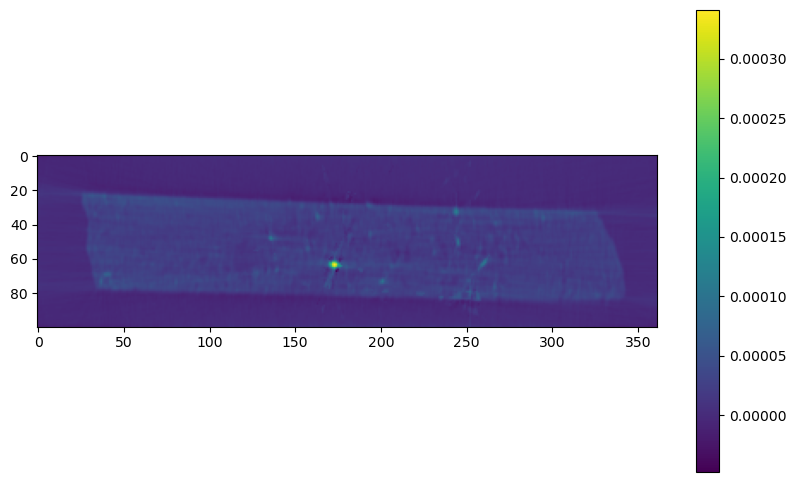

(100, 362, 2000)


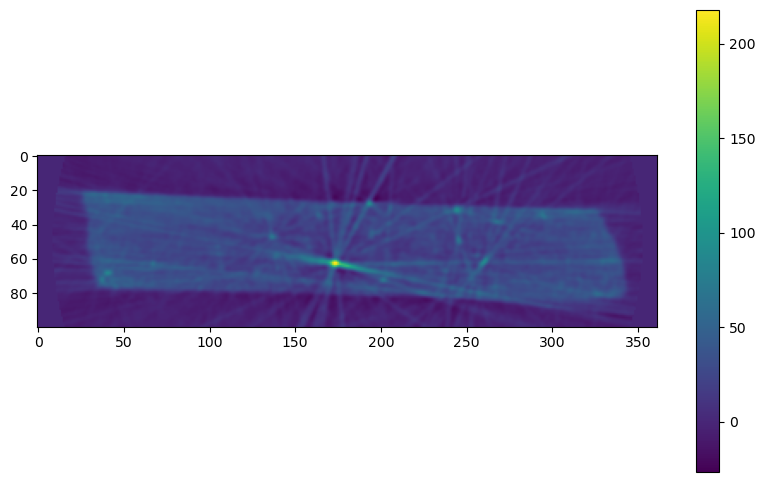

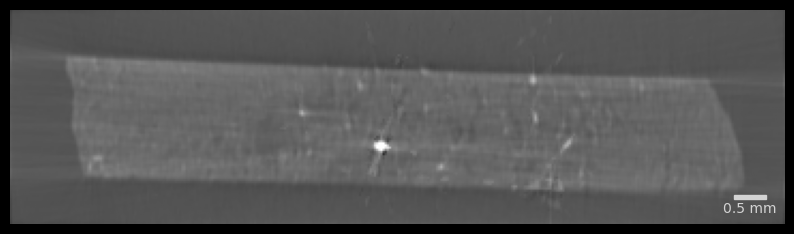

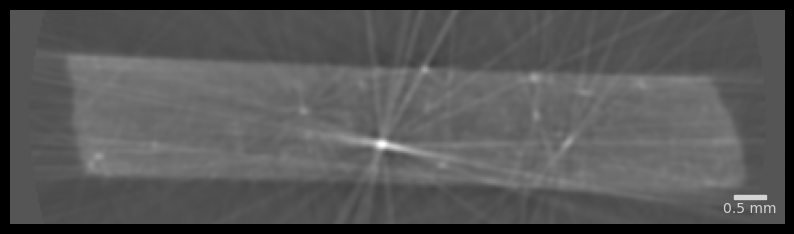

In [63]:

data_dir_gridrec = '/dtu-compute/msaca/sliceA_diffraction/xrd_reconstructions'
index_list_gridrec, all_files_gridrec = get_index_list_gridrec(data_dir_gridrec)

data_dir = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal'
theta_reg = False
index_list, all_files = get_index_list(data_dir, theta_reg = theta_reg, slice_index=0)
threshold = 2.5
scale_factor = 1

with h5py.File(all_files_gridrec[0], 'r') as f:
    data_g = {
        'recon': f['reconstructed/gridrec'][:][130:230,:,:],  # copy into memory
    }
recon = data_g['recon'][:]
with h5py.File(all_files[0], 'r') as f:
    data = {
        'powder-recon': f['powder-recon'][:][:,:,:],  # copy into memory
        'crystal-recon': f['crystal-recon'][:][:,:,:],
        'crystal-mask': f['crystal-mask'][:][:,:,:]}


powder = data['powder-recon'][:, :, :]
crystal = data['crystal-recon'][:, :, :]
mask_value = data['crystal-mask'][:,:, :]

combined = powder + crystal * (mask_value > threshold)
combined = combined * scale_factor
combined = combined.astype(np.float32)
combined = combined/np.sum(combined)*200

print(np.shape(combined))

N=430

plt.figure(figsize=(10,6))
plt.imshow(np.mean(combined[N-3:N+3],axis=0))
plt.colorbar()
plt.show()
print(np.shape(recon))
plt.figure(figsize=(10,6))
plt.imshow(np.mean(recon[:,:,3*N-9:3*N+9],axis=2))
plt.colorbar()
plt.show()




fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')

# Display the image

scale = 1
#im = ax.imshow(NA_[100:200,200:300], cmap='gray', vmin=-0.01, vmax = 0.07)
im = ax.imshow(np.mean(combined[N-3:N+3],axis=0), cmap='gray', vmin=-0.0001, vmax = 0.0002)

# Remove axes
ax.axis('off')
ax = add_scalebar(ax, 30, '0.5 mm', 1/2, color='lightgray')



fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')

# Display the image

scale = 1
#im = ax.imshow(NA_[100:200,200:300], cmap='gray', vmin=-0.01, vmax = 0.07)
im = ax.imshow(np.mean(recon[:,:,3*N-9:3*N+9],axis=2), cmap='gray', vmin=-100, vmax = 200)

# Remove axes
ax.axis('off')
ax = add_scalebar(ax, 30, '0.5 mm', 1/2, color='lightgray')


Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0429.h5 with shape (667, 100, 362)
Total samples: 36200
Making background plot


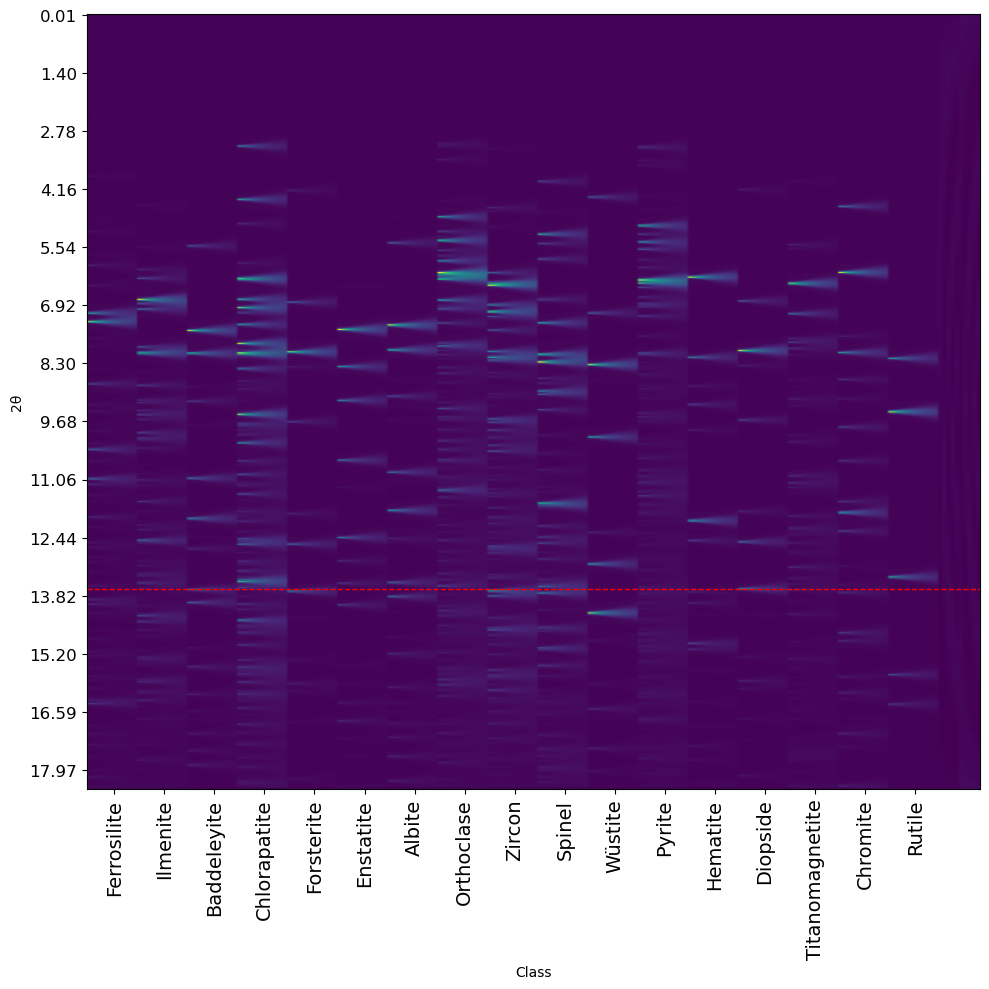

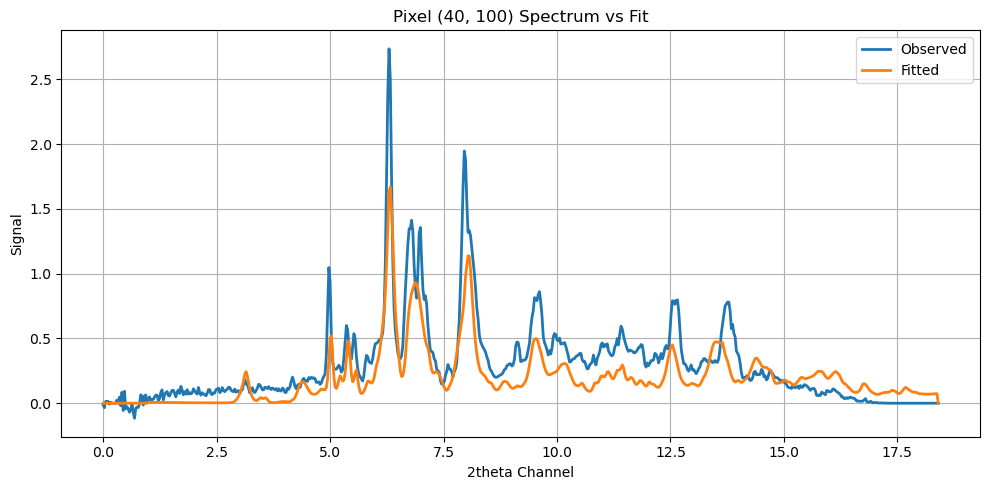

Name                      | Scaled Value
-----------------------------------------------------------------
Albite                    | 0.2457
Diopside                  | 0.2428
Ferrosilite               | 0.2069
Enstatite                 | 0.1328
Orthoclase                | 0.1063
Forsterite                | 0.0335
Titanomagnetite           | 0.0216
Rutile                    | 0.0077
Chromite                  | 0.0028


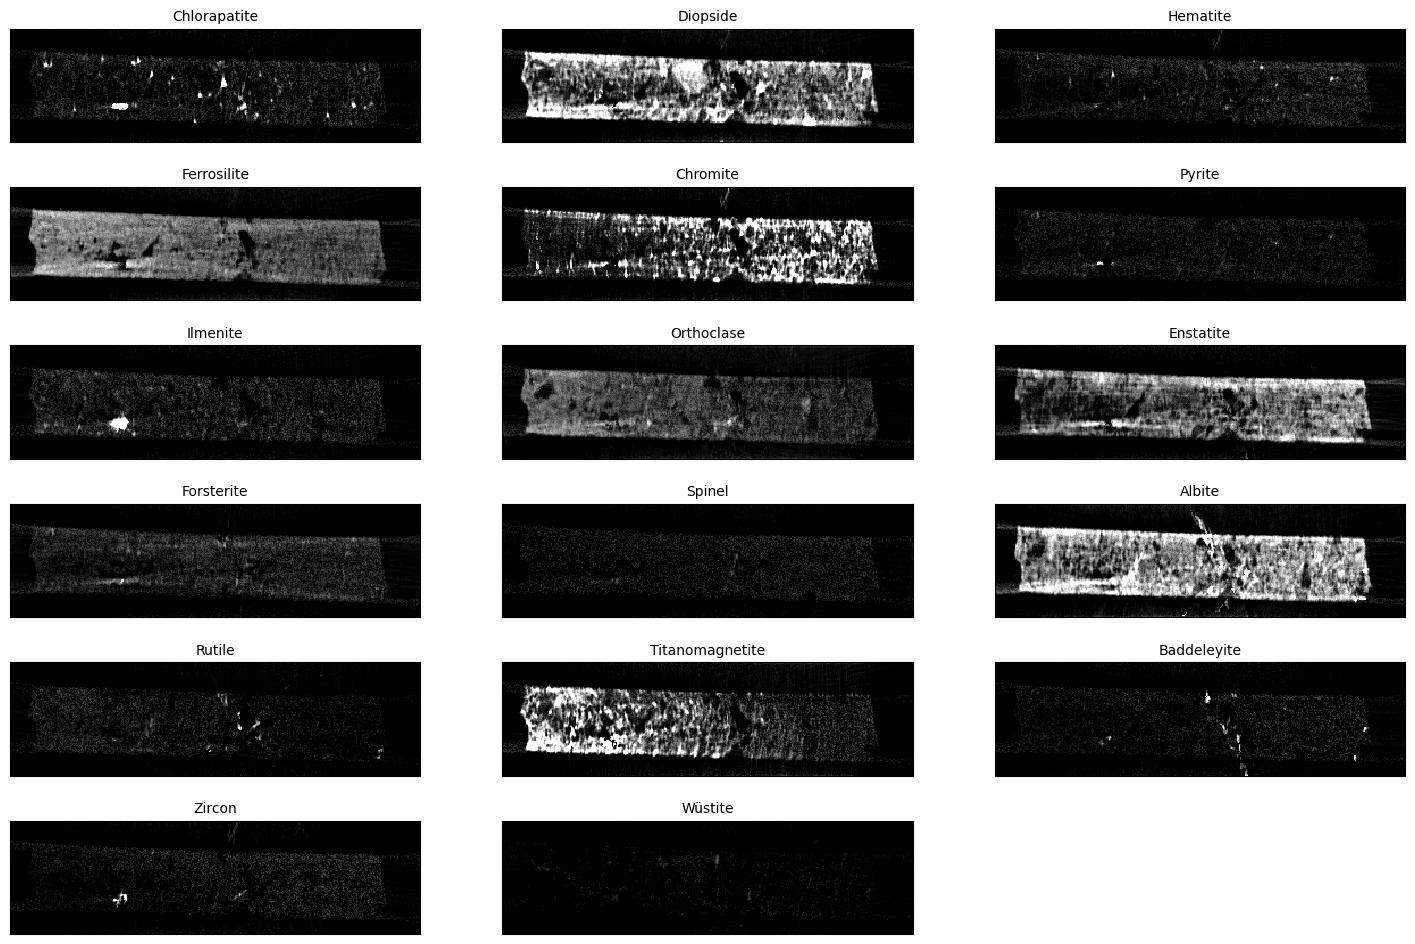

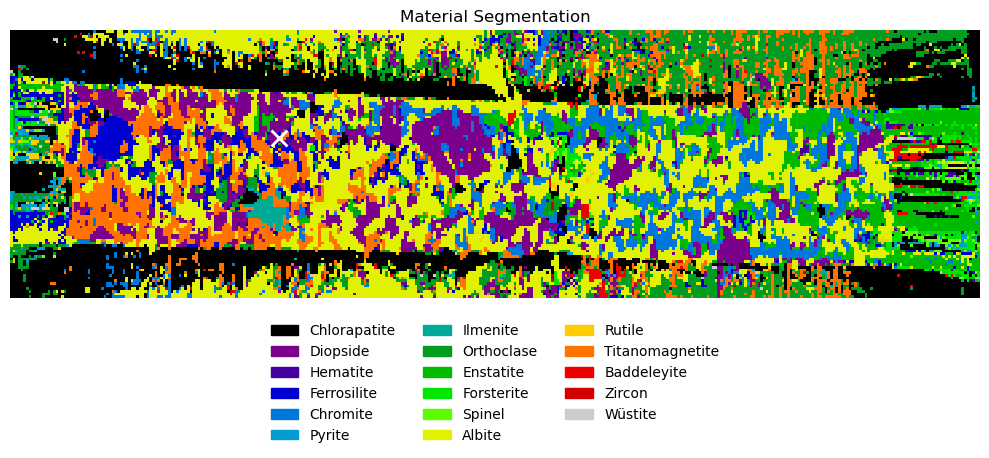

In [ ]:
data_dir = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal'
index_list, all_files = get_index_list(data_dir, theta_reg = theta_reg, slice_index=45)
dataset = ThresholdedH5Dataset(index_list, threshold=threshold)
N_2theta = 667
w = np.ones(N_2theta)
w[:100] = 0
A,materials = complete_full_segmentation_analysis(dataset,
                                    all_files,
                                    num_blur=12,
                                    method='GPU_Lasso',
                                    alpha=0.01,
                                    num_background=5,
                                    background_filter_sigma=None,
                                    box=None,
                                    w=w,
                                    j_global=40,
                                    k_global=100,
                                    N_2theta=N_2theta,
                                    display=True)

In [119]:
print('Number of materials:', num_materials)
print(spectra.keys())

Number of materials: 17
dict_keys(['Fe2Si2O6_pyroxene_ferrosilite', 'FeTiO3_ilmenite', 'ZrO2_baddeleyite', 'Ca5(PO4)3Cl_chlorapatite', 'Mg2SiO4_olivine_forsterite', 'Mg2Si2O6_pyroxene_enstatite', 'Na(AlSi3O8)_plagioclase_albite', 'K(AlSi3O8)_orthoclase_feldspar', 'ZrSiO4_zircon', 'MgAl2O4_spinel', 'wustite', 'FeS2_pyrite', 'Fe2O3_hematite', 'CaMgSi2O6_clinopyroxene_diopsite', 'Titanomagnetite', 'FeCr2O4_chromite', 'TiO2_rutile'])


In [120]:
threshold = 3.5
background_filter_sigma = None
box = [0,100, 0, 362]
smoothness_index = 9
alpha = 0.01
theta_reg = False
j_global, k_global = 40, 100
slice_index = 46
num_background = 5
ny = box[1] - box[0]
nx = box[3] - box[2]

In [121]:
key_to_name = simplified_keys()
keys = spectra.keys()
keys_simple = [key_to_name[k] for k in keys if k in key_to_name]
print(len(keys_simple))
data_dir = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal'
index_list, all_files = get_index_list(data_dir, theta_reg = theta_reg, slice_index=45)
dataset = ThresholdedH5Dataset(index_list, threshold=threshold)

data_dir_gridrec = '/dtu-compute/msaca/sliceA_diffraction/xrd_reconstructions'
index_list_gridrec, all_files_gridrec = get_index_list_gridrec(data_dir_gridrec)
dataset_gridrec = GridrecH5Dataset(index_list_gridrec)
print(dataset_gridrec[0].shape)

17
Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0429.h5 with shape (667, 100, 362)
Total samples: 36200
Processing /dtu-compute/msaca/sliceA_diffraction/xrd_reconstructions/scan-339_recon.h5 with shape (2000, 362, 362)
Total samples: 131044
(2000,)


(2000, 214)


ValueError: x and y must have same first dimension, but have shapes (667,) and (2000,)

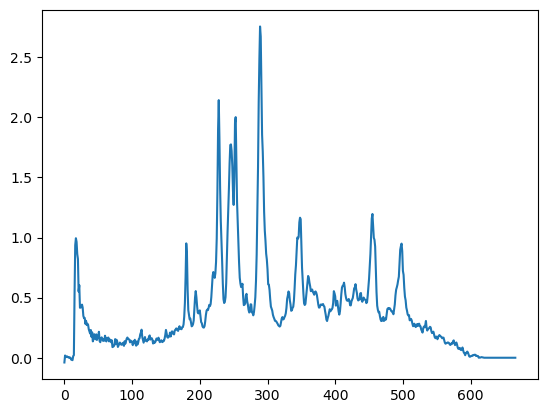

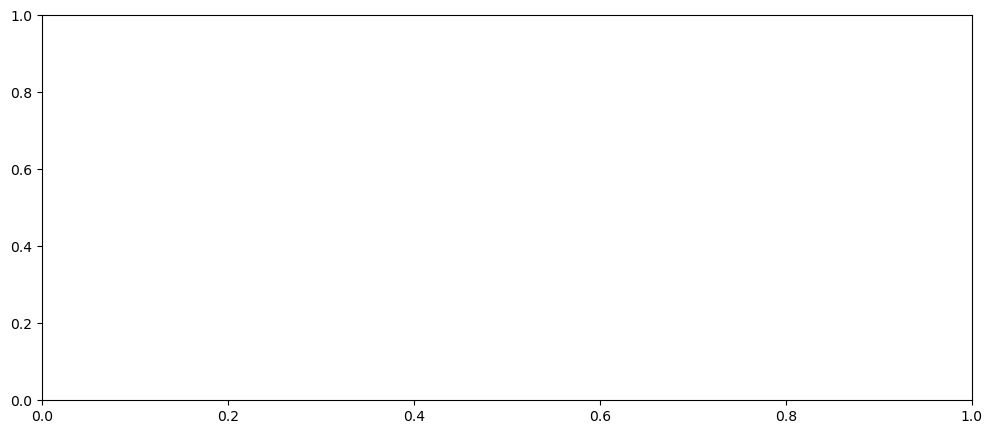

In [ ]:
N_2theta = 2000
#A, keys = resample_basis_dict(spectra, smoothness_index, np.linspace(0, 18.4, N_2theta))
A, keys = resample_all_blurs(spectra, start_col=2, target_x=np.linspace(0.01, 18.408, N_2theta))
if background_filter_sigma is None:
    A = add_fourier_background_basis(A, np.linspace(0,18.4,N_2theta), num_frequencies=num_background)
print(np.shape(A))

H, total_columns = A.shape
N = len(keys_simple)
M = total_columns // N
x_positions = [M * (i + 0.5) for i in range(N)]  # center of each class block

if background_filter_sigma is None:
    A_subset = A[:,7:-2*num_background:num_blur]
else:
    A_subset = A[:,7::num_blur]

A_max = np.max(A_subset,axis=1)/(np.sum(A_subset,axis=1)+0.0001)
A_argmax = np.argmax(A_subset,axis=1)
# Example: class of interest

j_global = 40
k_global = 80
filename_gridrec = all_files_gridrec[0]
filename = all_files[0]
# Define the materials to highlight
target_classes = ['Ferrosilite', 'Ilmenite', 'Baddeleyite', 'Chlorapatite', 'Forsterite', 'Enstatite', 'Albite', 'Orthoclase', 'Zircon', 'Spinel', 'Wüstite', 'Pyrite', 'Hematite', 'Diopside', 'Titanomagnetite', 'Chromite', 'Rutile']  # example
idx = dataset_gridrec.index_list.index((filename_gridrec,j_global, k_global))
y1 = dataset_gridrec[idx]

idx = dataset.index_list.index((filename, j_global, k_global))
y2_ = dataset[idx]
x = np.linspace(0.01, 18.408, 667)
f_interp = interp1d(x, y2_, kind='linear')
y2 = f_interp(twotheta)

#plt.plot(y2_)
#peak_plot(target_classes, [y1,y2*100], A_argmax, keys_simple, twotheta)


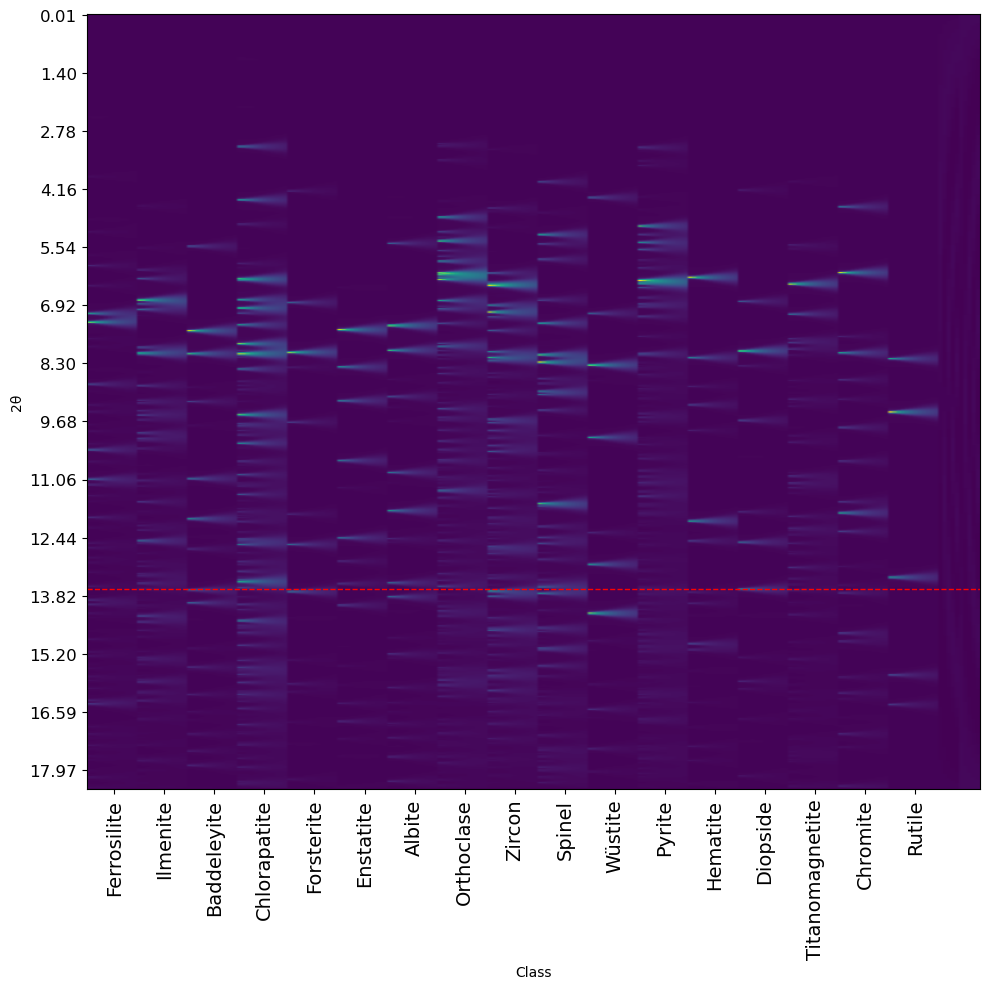

In [ ]:
# Example: show every Nth tick for readability
N_2theta = np.shape(A)[0]
twotheta = np.linspace(0.0145, 18.408, N_2theta)
step = 50  # adjust based on your data size
yticks = np.arange(0, len(twotheta), step)
ytick_labels = [f"{twotheta[i]:.2f}" for i in yticks]

plt.figure(figsize=(10, 10))
plt.imshow(A, aspect='auto', cmap='viridis')
plt.xticks(ticks=x_positions, labels=keys_simple, rotation=90, fontsize=14)
plt.yticks(ticks=yticks, labels=ytick_labels, fontsize=12)
plt.xlabel("Class")
plt.ylabel("2θ")
plt.tight_layout()
# Find closest index in twotheta
target_twotheta = 13.65
y_index = np.argmin(np.abs(twotheta - target_twotheta))

# Then draw the line
plt.axhline(y=y_index, color='red', linestyle='--', linewidth=1)
plt.show()

In [128]:
dataset = dataset
N_2theta = 667
twotheta = np.linspace(0.0145,18.408, N_2theta)
w = np.ones(N_2theta, dtype=np.float32)
w[:100] = 0
#w[np.abs(twotheta-13.5)<0.1] = 10000




#A, keys = resample_basis_dict(spectra, smoothness_index, np.linspace(0, 18.4, N_2theta))
A, keys = resample_all_blurs(spectra, start_col=2, target_x=np.linspace(0.00, 18.4, N_2theta))
if background_filter_sigma is None:
    A = add_fourier_background_basis(A, np.linspace(0,18.4,N_2theta), num_frequencies=num_background)

H, total_columns = A.shape
N = len(keys_simple)
M = total_columns // N
materials1 = fit_all_pixels(dataset, A, alpha=alpha, box=box, background_filter_sigma=background_filter_sigma, method='GPU_Lasso', w=w)


In [129]:
materials2 = fit_all_pixels(dataset, A, alpha=alpha, box=box, background_filter_sigma=background_filter_sigma, method='GPU_Lasso')

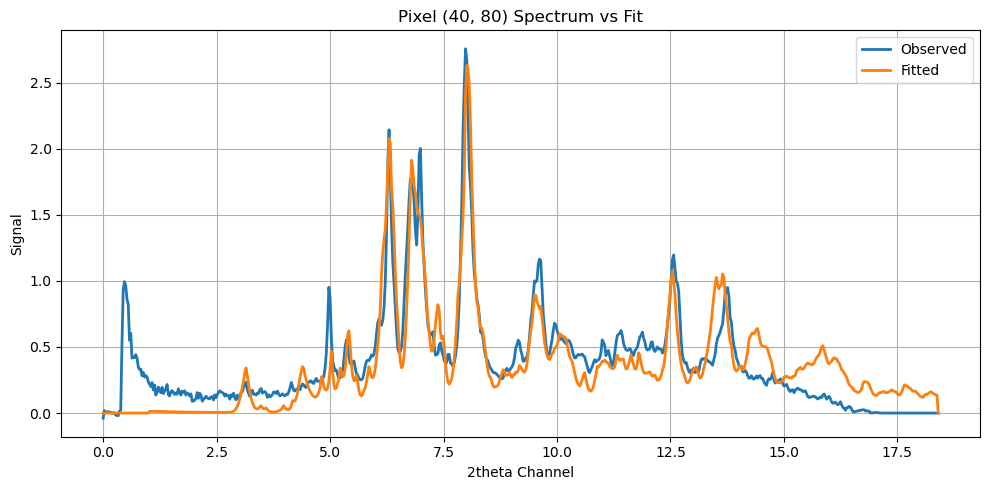

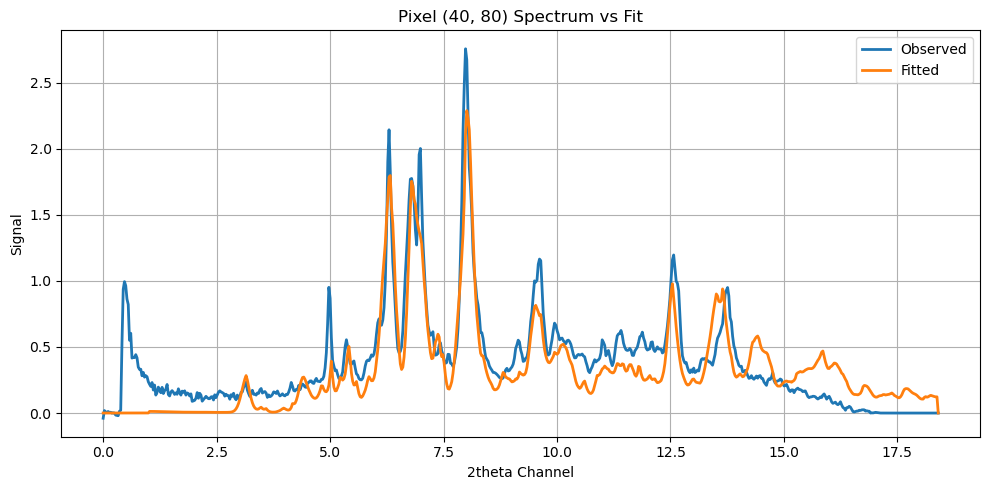

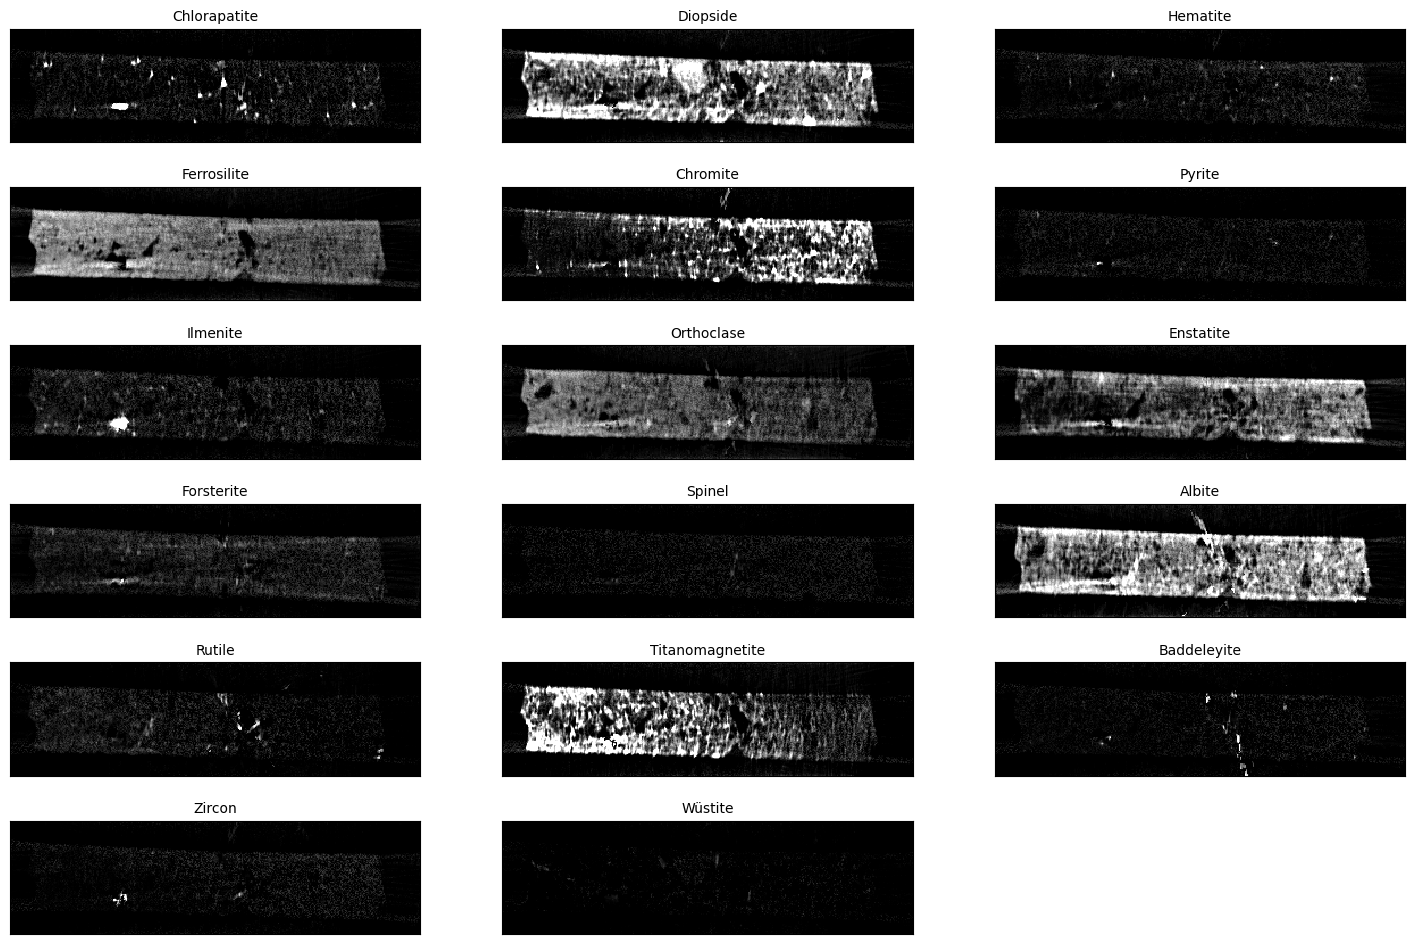

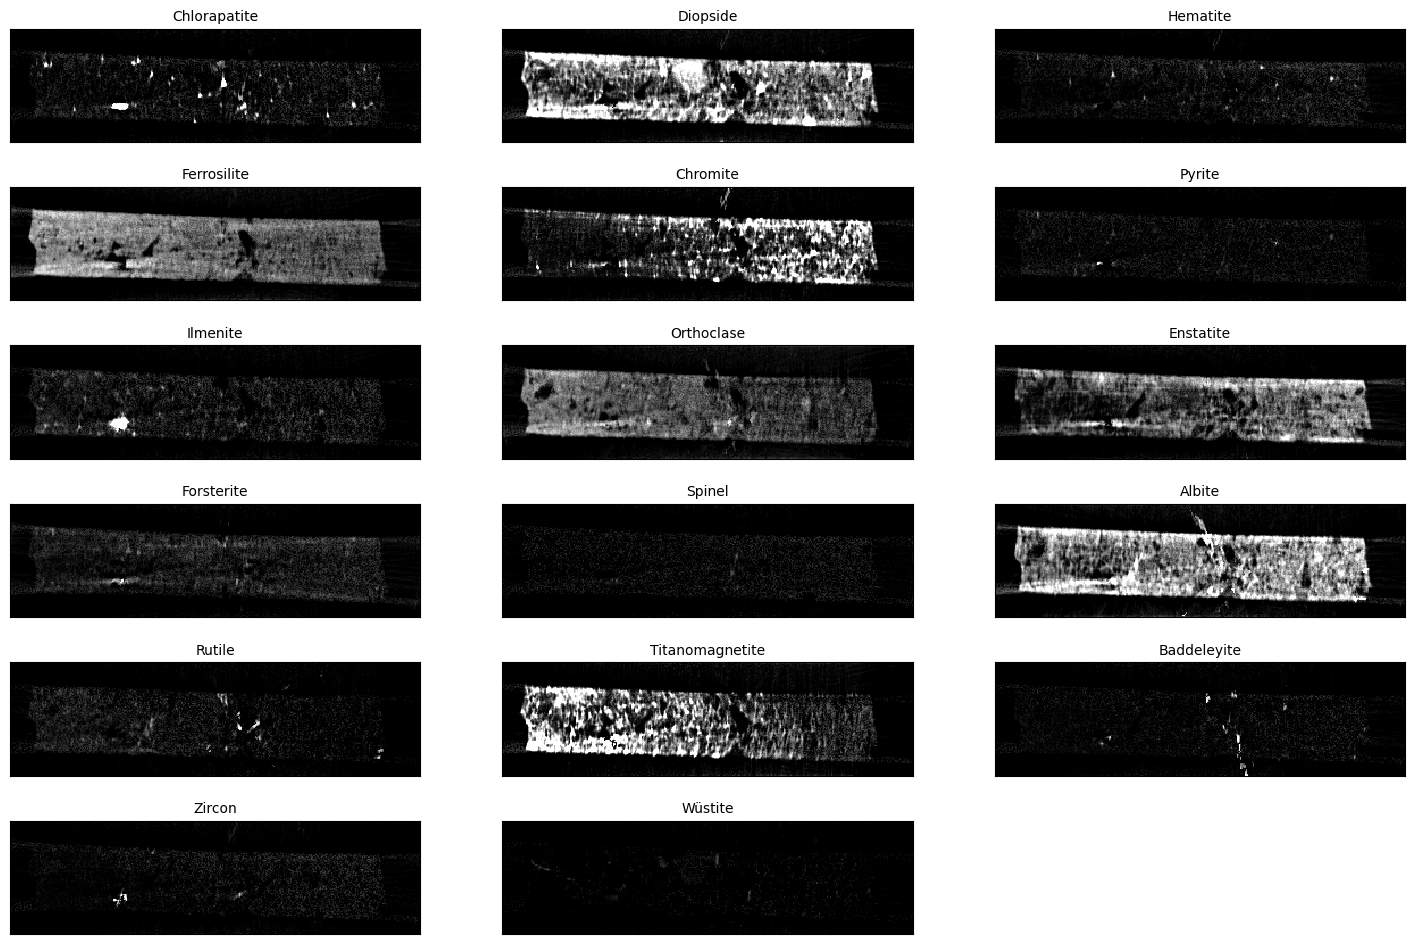

In [130]:
plot_pixel_fit(j_global=j_global, k_global=k_global, dataset=dataset, materials=materials1,
               A=A, box=box,filename=all_files[0], background_filter_sigma=background_filter_sigma)

plot_pixel_fit(j_global=j_global, k_global=k_global, dataset=dataset, materials=materials2,
               A=A, box=box,filename=all_files[0], background_filter_sigma=background_filter_sigma)

materials1_mean = materials1[:-2*num_background].reshape(num_materials, num_blur, *materials1.shape[1:]).mean(axis=1)
materials2_mean = materials2[:-2*num_background].reshape(num_materials, num_blur, *materials2.shape[1:]).mean(axis=1)

plot_material_maps_only(materials1_mean, keys, key_to_name, num_cols=3)
plot_material_maps_only(materials2_mean, keys, key_to_name, num_cols=3)
#plt.savefig('/dtu-compute/msaca/sliceA_diffraction/figures/example_decomp.png',dpi=500, bbox_inches='tight')


In [131]:
if background_filter_sigma is None:
    materials1_ = materials1[:-(2*num_background)]
    materials2_ = materials2[:-(2*num_background)]

materials1_4d = materials1_.reshape(num_materials, num_blur, ny, nx)
materials1_summed = materials1_4d.sum(axis=1)
materials2_4d = materials2_.reshape(num_materials, num_blur, ny, nx)
materials2_summed = materials2_4d.sum(axis=1)

print_nonzero_material_coeffs(materials1_summed[:,j_global-box[0],k_global-box[2]], keys, key_to_name, num_background=6, threshold=1e-8)
print_nonzero_material_coeffs(materials2_summed[:,j_global-box[0],k_global-box[2]], keys, key_to_name, num_background=6, threshold=1e-8)


Name                      | Scaled Value
-----------------------------------------------------------------
Diopside                  | 0.2383
Ferrosilite               | 0.1541
Enstatite                 | 0.0993
Orthoclase                | 0.0958
Albite                    | 0.0765
Titanomagnetite           | 0.0736
Chromite                  | 0.0497
Forsterite                | 0.0428
Ilmenite                  | 0.0415
Pyrite                    | 0.0309
Spinel                    | 0.0304
Hematite                  | 0.0249
Chlorapatite              | 0.0210
Zircon                    | 0.0103
Rutile                    | 0.0076
Baddeleyite               | 0.0034
Name                      | Scaled Value
-----------------------------------------------------------------
Diopside                  | 0.2899
Ferrosilite               | 0.1737
Enstatite                 | 0.1150
Orthoclase                | 0.1006
Albite                    | 0.0789
Titanomagnetite           | 0.0744
Forsterite      

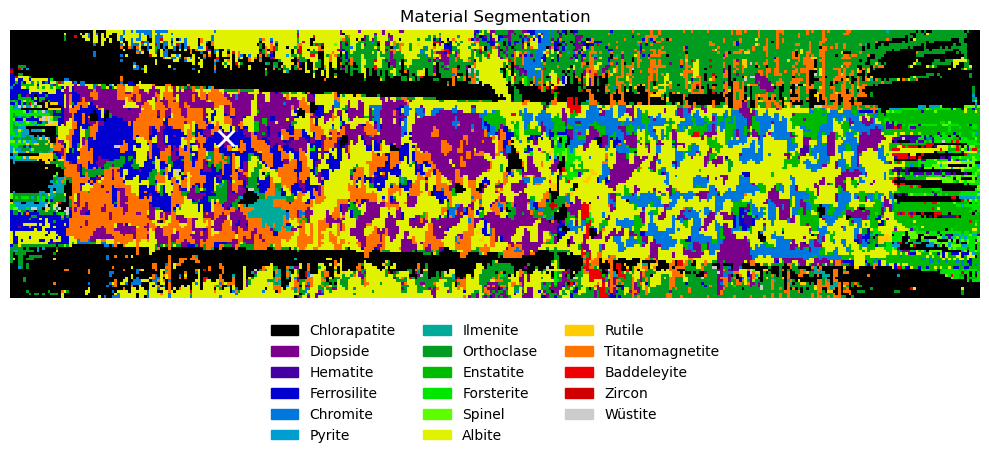

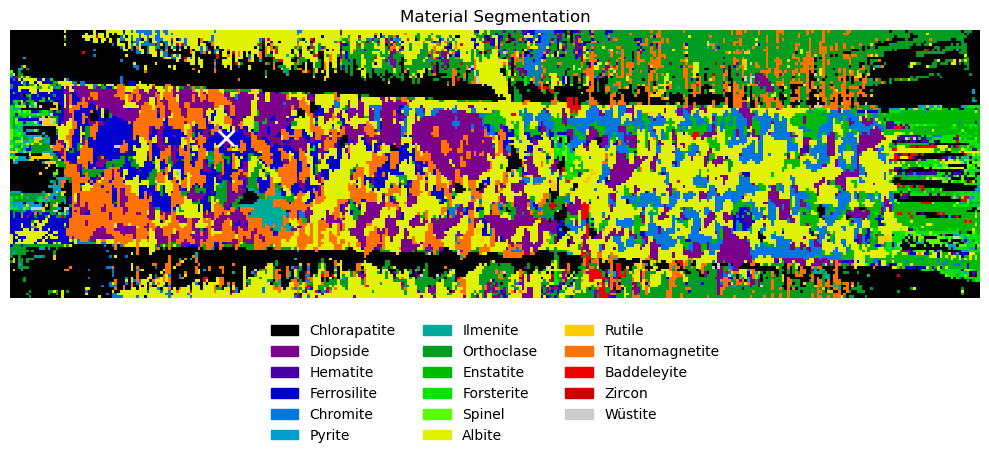

In [132]:
import matplotlib.patches as mpatches


# Compute segmentation
segmentation1 = np.argmax(materials1_summed, axis=0)
segmentation2 = np.argmax(materials2_summed, axis=0)

# Plot
plt.figure(figsize=(10, 8))
cmap = plt.get_cmap('nipy_spectral', len(keys))
im = plt.imshow(segmentation1, cmap=cmap, interpolation='none')
plt.title("Material Segmentation")
plt.axis('off')

# Add markers
plt.plot(k_global- box[2], j_global - box[0], 'x', color='white', markersize=12, markeredgewidth=2)

# Legend below
unique_ids = np.unique(segmentation1)
legend_handles = [
    mpatches.Patch(color=cmap(i), label=key_to_name[keys[i]]) for i in unique_ids
]
plt.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()


# Plot
plt.figure(figsize=(10, 8))
cmap = plt.get_cmap('nipy_spectral', len(keys))
im = plt.imshow(segmentation2, cmap=cmap, interpolation='none')
plt.title("Material Segmentation")
plt.axis('off')

# Add markers
plt.plot(k_global- box[2], j_global - box[0], 'x', color='white', markersize=12, markeredgewidth=2)

# Legend below
unique_ids = np.unique(segmentation2)
legend_handles = [
    mpatches.Patch(color=cmap(i), label=key_to_name[keys[i]]) for i in unique_ids
]
plt.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()





In [19]:
data = materials1_mean
L, M, N = data.shape
num_samples = 2000  # t-SNE is slow; choose reasonably
indices = np.random.choice(M*N, size=num_samples, replace=False)

In [159]:
data_reshaped = data.reshape(L, -1).T  # shape: (M*N, L)

# Step 1: Sample 5–10% for UMAP fitting
num_total = data_reshaped.shape[0]
num_sample = int(num_total * 0.01)
sampled_data = data_reshaped[indices]
pca = PCA(n_components=3)
sampled_data_pca = pca.fit_transform(sampled_data)  # shape: (num_samples, 3)

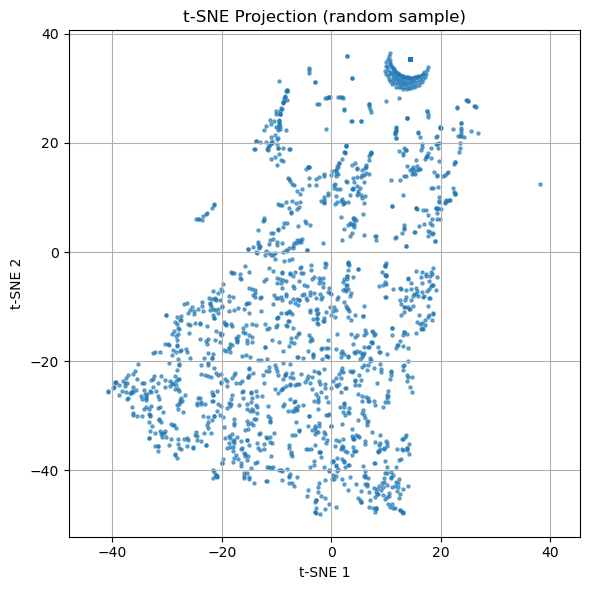

In [198]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Reshape: each vector is (L,) at position (j, i)
data_reshaped = data.reshape(L, -1).T  # shape: (N*M, L)

# Optional: sample to reduce computation time
sampled_data = data_reshaped[indices]
full_data_reshaped = data.reshape(L, -1).T  # shape (M*N, L)

# Apply t-SNE
tsne = TSNE(n_components=2, init='random', random_state=0, perplexity=30)
tsne_result = tsne.fit_transform(sampled_data)  # shape: (num_samples, 2)


# Plot
plt.figure(figsize=(6, 6))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=5, alpha=0.6)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE Projection (random sample)')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [100]:
from sklearn.cluster import KMeans

tsne = TSNE(n_components=3, init='random', random_state=0, perplexity=30)
tsne_result3 = tsne.fit_transform(sampled_data)  # shape: (num_samples, 2)

In [199]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=15, covariance_type='full', random_state=0)
labels = gmm.fit_predict(sampled_data)

In [202]:

k = 15  # choose based on prior knowledge or try multiple
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(tsne_result)  # shape: (num_samples,)

In [207]:
# Step 1: Fit UMAP on sampled_data
umap_model = umap.UMAP(n_components=3, random_state=0)
umap_embedded = umap_model.fit_transform(sampled_data)  # shape: (num_samples, 3)
umap_full = umap_model.transform(full_data_reshaped)  # shape: (M*N, 3)

# Step 2: Cluster the UMAP result
k = 15  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(umap_embedded)  # or use GMM if preferred

k = 15  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=0)
labels_full = kmeans.fit_predict(umap_full)  # or use GMM if preferred

/dtu-compute/msaca/conda3/envs/cil6/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/dtu-compute/msaca/conda3/envs/cil6/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/dtu-compute/msaca/conda3/envs/cil6/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


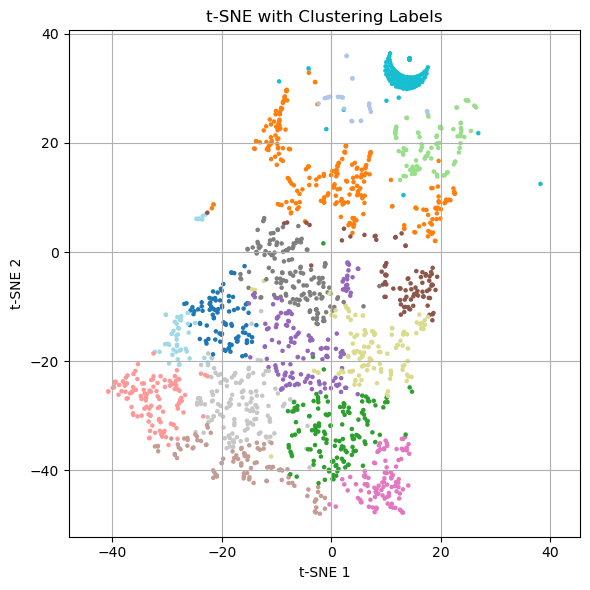

In [206]:

plt.figure(figsize=(6, 6))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap='tab20', s=5)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE with Clustering Labels')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
# Standardize data (optional but recommended)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_reshaped)

# Fit GMM
k = 10  # number of clusters; adjust as needed
gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
labels_flat = gmm.fit_predict(data_scaled)  # shape: (N*M,)

# Reshape to (N, M)


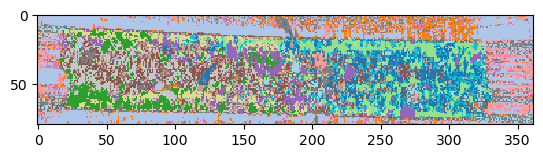

In [210]:
labels_full_ = labels_full.reshape(M, N)
plt.imshow(labels_full_, cmap='tab20', interpolation='none')

In [30]:
import pandas as pd

# ---- 1. From materials_summed ----
material1_totals = materials1_summed.sum(axis=(1, 2))
total_sum = material1_totals.sum()
percentages1_soft = 100 * material1_totals / total_sum
material1_names = [key_to_name[key] for key in keys]

# ---- 2. From argmax segmentation ----
unique_ids, counts = np.unique(segmentation1, return_counts=True)
total_pixels = segmentation1.size
percentages1_hard = np.zeros(len(keys))
percentages1_hard[unique_ids] = 100 * counts / total_pixels

# ---- 3. Combine into a DataFrame ----
df_combined = pd.DataFrame({
    'Material': material1_names,
    'Soft Percentage': percentages1_soft,
    'Hard Percentage': percentages1_hard
})

# Sort by hard segmentation result
df_combined_sorted = df_combined.sort_values(by='Hard Percentage', ascending=False).reset_index(drop=True)

# ---- 4. Print ----
print(df_combined_sorted.to_string(
    index=False,
    formatters={
        'Soft Percentage': '{:.2f}%'.format,
        'Hard Percentage': '{:.2f}%'.format
    }
))


       Material Soft Percentage Hard Percentage
         Albite          15.99%          22.65%
   Chlorapatite           2.72%          22.01%
       Diopside          14.96%          13.40%
Titanomagnetite          11.86%          12.56%
       Chromite           9.35%           7.21%
    Ferrosilite          11.24%           5.67%
      Enstatite           9.41%           5.22%
     Orthoclase           8.32%           4.97%
     Forsterite           3.24%           1.42%
         Rutile           2.01%           0.95%
       Ilmenite           3.62%           0.77%
         Pyrite           1.29%           0.77%
    Baddeleyite           1.23%           0.74%
       Hematite           1.82%           0.64%
         Spinel           1.26%           0.64%
        Wüstite           0.34%           0.25%
         Zircon           1.34%           0.16%


In [237]:
idx = 200+100*100
y = dataset[idx]  # shape (667,)
if background_filter_sigma is not None:
    background = gaussian_filter1d(y, sigma=background_filter_sigma)
    foreground = y - background
    foreground[foreground < 0] = 0
    plt.figure(figsize=(10, 5))
    plt.plot(y)
    plt.plot(background)
    plt.plot(foreground)
    plt.title('Background and Foreground Separation')
    plt.legend(['Original', 'Background', 'Foreground'])
    plt.show()


In [238]:
importlib.reload(sys.modules['interactive_notebooks.n21_attachment'])
from interactive_notebooks.n21_attachment import *
similarity = compute_similarity_matrix(A, num_materials=17, num_blur=num_blur, alpha=0.1, mask_rows=100)


In [239]:
import seaborn as sns
if background_filter_sigma is not None:
    i_mat = 3
    num_materials = 17
    i_blur = 3
    print(keys_simple[i_mat])
    num_blur = 6

    A_red, y = A_reduced(A, i_mat, num_materials, i_blur, num_blur, mask_rows=0)
    similarity_means = similarity.mean(axis=(1, 3))  # shape: (29, 29)
    # Plot heatmap
    plt.figure(figsize=(10, 10))
    sns.heatmap(similarity_means, cmap="viridis", square=True, cbar=True,
                xticklabels=keys_simple, yticklabels=keys_simple)
    plt.title("Mean Similarity Between Materials (Confusion Matrix Style)")
    plt.xlabel("Compared Material (j)")
    plt.ylabel("Target Material (i)")
    plt.tight_layout()
    plt.show()

    similarity_ = similarity.reshape(num_materials, num_blur, -1)

    print(np.shape(A_red))
    print(np.shape(y))
    print(np.shape(similarity_))
    pred = A@(similarity_[i_mat, i_blur, :])
    plt.figure(figsize=(10, 5))
    plt.plot(pred, label='Predicted')
    plt.plot(y, label='True')
    plt.title('Predicted vs True')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(similarity_means.sum(axis=1))
    plt.show()

In [240]:
17*6*17*6

10404

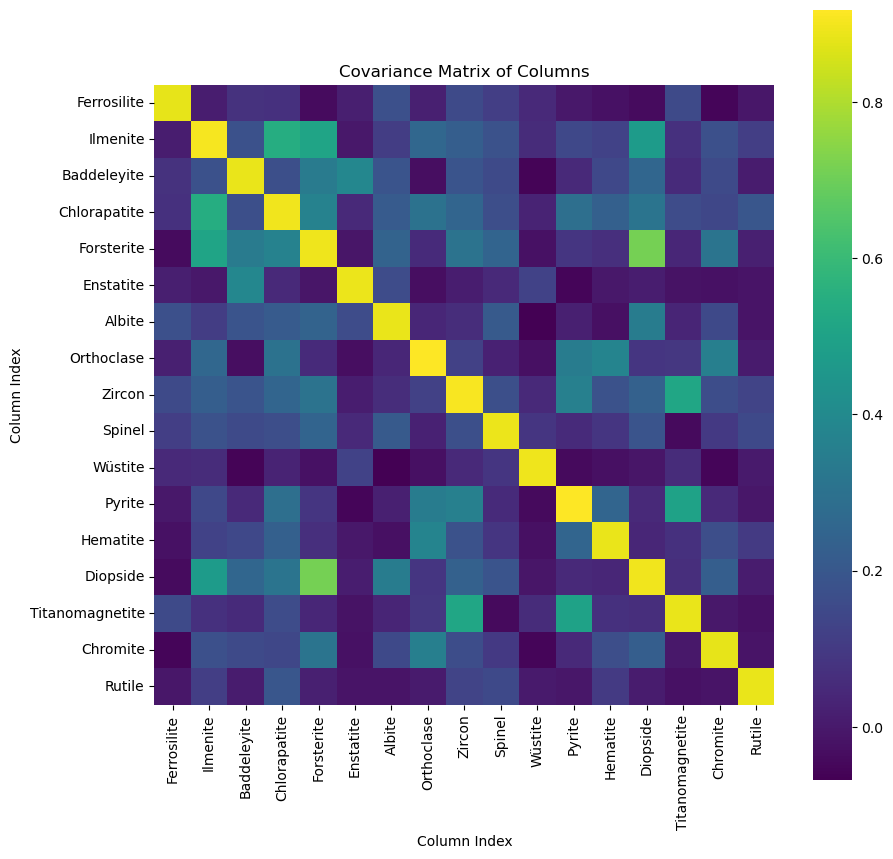

In [241]:
# Center the data (optional but common in covariance)
A_ = A[:,:-2*num_background]
A_centered = (A_ - A_.mean(axis=0))/A_.std(axis=0)

key_to_name = simplified_keys()
keys = spectra.keys()
keys = sorted(spectra.keys())
keys_simple = [key_to_name[k] for k in keys if k in key_to_name]
# Compute covariance matrix of columns
cov = np.cov(A_centered, rowvar=False)  # shape: (n_columns, n_columns)
# Assume M is your (174, 174) matrix, where 174 = 29 * 6
# Reshape into 4D: (29, 6, 29, 6)
cov_blocks = cov.reshape(num_materials, num_blur, num_materials, num_blur)

# Average over the 6×6 blocks (axes 1 and 3)
cov_collapsed = cov_blocks.mean(axis=(1, 3))  # shape: (29, 29)

plt.figure(figsize=(10, 10))
sns.heatmap(cov_collapsed, cmap="viridis", square=True, cbar=True,
            xticklabels=keys_simple, yticklabels=keys_simple)
#plt.imshow(cov_collapsed, cmap='viridis')
#plt.colorbar()
plt.title("Covariance Matrix of Columns")
plt.xlabel("Column Index")
plt.ylabel("Column Index")
plt.show()

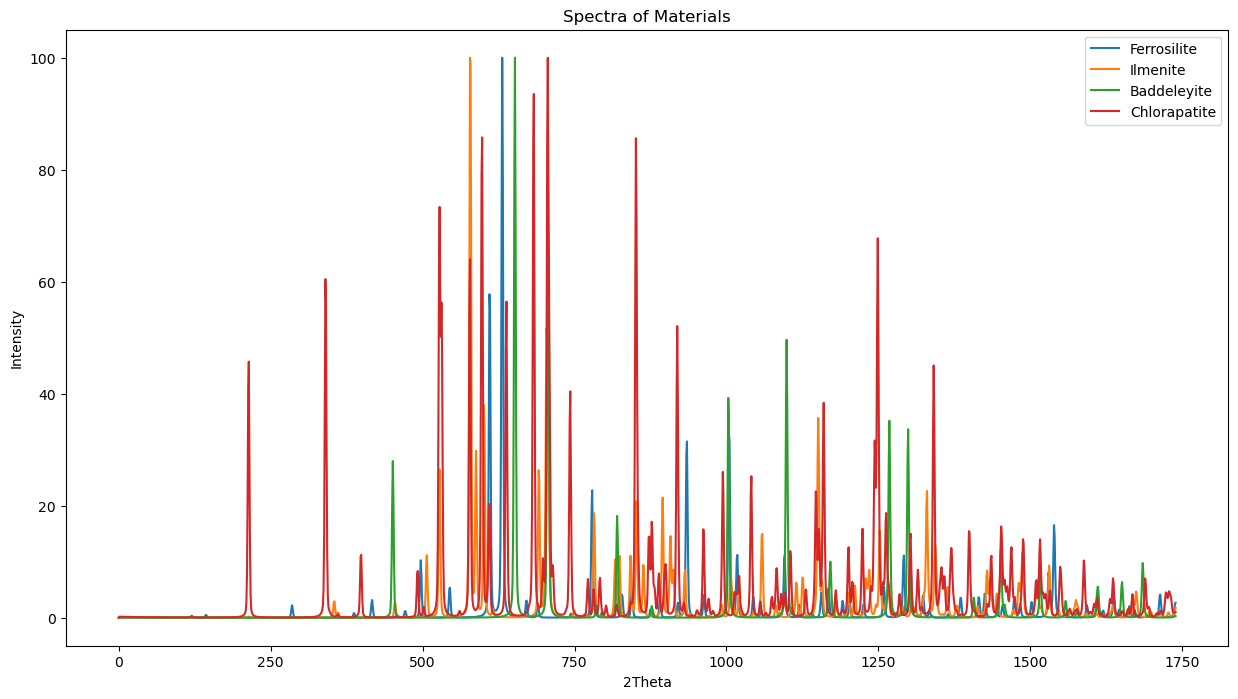

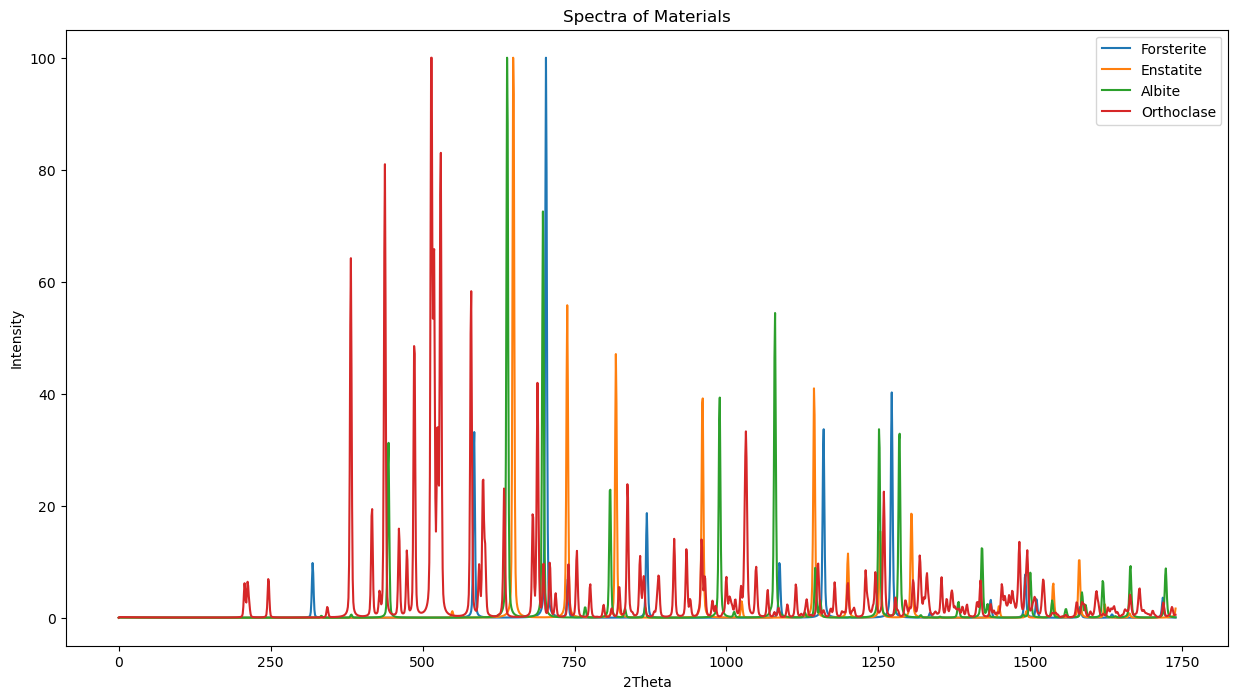

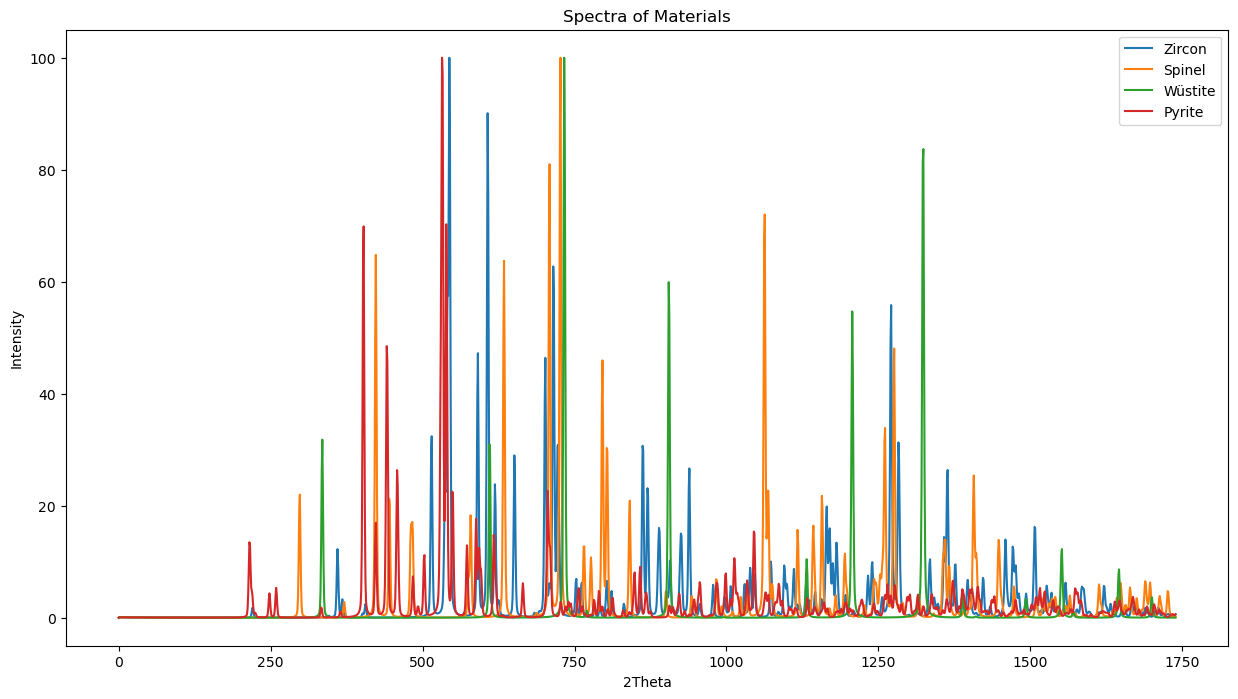

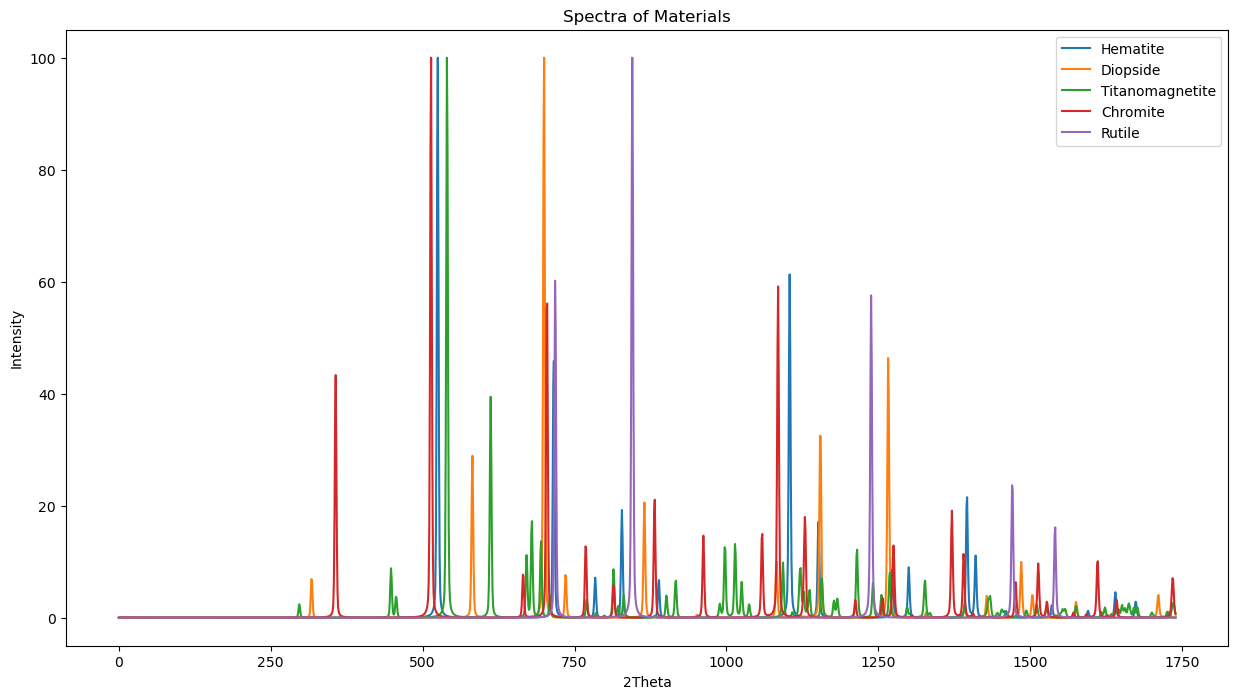

In [242]:
plt.figure(figsize=(15, 8))
for i in range(0,4):
    plt.plot(spectra[keys[i]][:, 2], label=keys_simple[i])
plt.title("Spectra of Materials")
plt.xlabel("2Theta")
plt.ylabel("Intensity")
plt.legend()
plt.show()

plt.figure(figsize=(15, 8))
for i in range(4,8):
    plt.plot(spectra[keys[i]][:, 2], label=keys_simple[i])
plt.title("Spectra of Materials")
plt.xlabel("2Theta")
plt.ylabel("Intensity")
plt.legend()
plt.show()

plt.figure(figsize=(15, 8))
for i in range(8,12):
    plt.plot(spectra[keys[i]][:, 2], label=keys_simple[i])
plt.title("Spectra of Materials")
plt.xlabel("2Theta")
plt.ylabel("Intensity")
plt.legend()
plt.show()

plt.figure(figsize=(15, 8))
for i in range(12,17):
    plt.plot(spectra[keys[i]][:, 2], label=keys_simple[i])
plt.title("Spectra of Materials")
plt.xlabel("2Theta")
plt.ylabel("Intensity")
plt.legend()
plt.show()

In [139]:
import torch
from geomloss import SamplesLoss
y = dataset[100+362*50]
lambda_l1 = 0.0005
A, keys = resample_basis_dict(spectra, 4, np.linspace(0, 18.4, 667))
A = add_background_basis(A, np.linspace(0, 18.4, 667), degree=2)
A_ = torch.tensor(A[100:], dtype=torch.float32)
from scipy.ndimage import gaussian_filter1d


background = als_baseline(y)
foreground = y - background
foreground[foreground < 0] = 0
y_ = torch.tensor(foreground[100:], dtype=torch.float32)
y_ = y_ / y_.sum()  # Normalize
y_ = y_.view(-1, 1)

# Initialize c (40,), requires grad
c = torch.nn.Parameter(torch.ones(A_.shape[1], dtype=torch.float32), requires_grad=True)

# Sinkhorn loss (Wasserstein-1 with blur)
loss1_fn = SamplesLoss("sinkhorn", p=1, blur=0.000005)  # adjust blur for strength
loss2_fn = SamplesLoss("sinkhorn", p=2, blur=0.000005) 

optimizer = torch.optim.Adam([c], lr=0.5)

positions = torch.arange(567, dtype=torch.float32).reshape(-1, 1)
for step in range(100):
    optimizer.zero_grad()

    pred = torch.matmul(A_, torch.clamp(c, min=0))
    pred = pred / pred.sum()  # normalize prediction
    pred = pred.view(-1, 1)
    sinkhorn1_loss = loss1_fn(positions, pred, positions, y_)
    sinkhorn2_loss = loss2_fn(positions, pred, positions, y_)
    l1_penalty = torch.sum(torch.clamp(c, min=0))
    loss = sinkhorn1_loss + sinkhorn2_loss + lambda_l1 * l1_penalty
    loss.backward()
    optimizer.step()

    if step % 20 == 0:
        print(f"Step {step}, Loss = {loss.item():.4f}")
pred = pred.detach().cpu().numpy()


Step 0, Loss = 216.6871
Step 20, Loss = 36.1440
Step 40, Loss = 34.5459
Step 60, Loss = 34.3092
Step 80, Loss = 34.2663


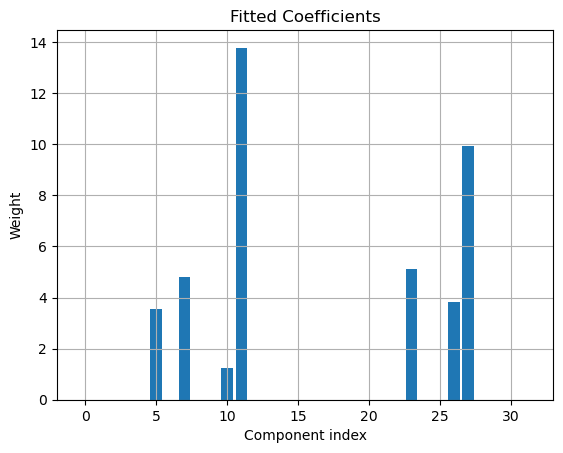

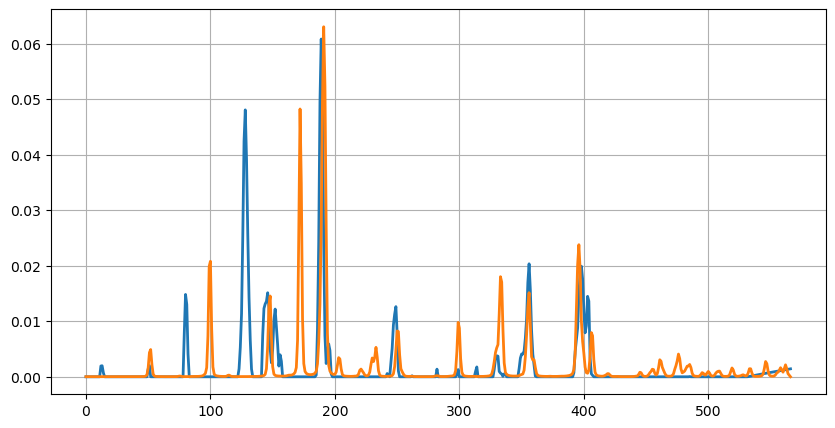

In [203]:
coeffs = torch.clamp(c, min=0).detach().cpu().numpy()
plt.bar(range(len(coeffs)), coeffs)
plt.title("Fitted Coefficients")
plt.xlabel("Component index")
plt.ylabel("Weight")
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(y_.numpy(), label='Observed', linewidth=2)
plt.plot(pred, label='Observed', linewidth=2)
plt.grid(True)
plt.show()
